<a href="https://colab.research.google.com/github/samp3209/Sandboxes/blob/main/NLPAssignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import string
import gensim

In [12]:
df = pd.read_csv('quotes.csv')
df.head()

,quote,author,category
0,"I'm selfish, impatient and a little insecure. ...",Marilyn Monroe,"attributed-no-source, best, life, love, mistak..."
1,You've gotta dance like there's nobody watchin...,William W. Purkey,"dance, heaven, hurt, inspirational, life, love..."
2,You know you're in love when you can't fall as...,Dr. Seuss,"attributed-no-source, dreams, love, reality, s..."
3,A friend is someone who knows all about you an...,Elbert Hubbard,"friend, friendship, knowledge, love"
4,Darkness cannot drive out darkness: only light...,"Martin Luther King Jr., A Testament of Hope: T...","darkness, drive-out, hate, inspirational, ligh..."


In [13]:
#extract only the author by only selecting the text before the first comma if exists
#assumes that all the rows with extra detail is after a comma
df['author'] =  df['author'].str.extract(r'^([^,]+)')
#remove periods
df['author'] = df['author'].str.replace('.', '')
#string to lower
df['author'] = df['author'].str.lower()
df.head()

,quote,author,category
0,"I'm selfish, impatient and a little insecure. ...",marilyn monroe,"attributed-no-source, best, life, love, mistak..."
1,You've gotta dance like there's nobody watchin...,william w purkey,"dance, heaven, hurt, inspirational, life, love..."
2,You know you're in love when you can't fall as...,dr seuss,"attributed-no-source, dreams, love, reality, s..."
3,A friend is someone who knows all about you an...,elbert hubbard,"friend, friendship, knowledge, love"
4,Darkness cannot drive out darkness: only light...,martin luther king jr,"darkness, drive-out, hate, inspirational, ligh..."


In [14]:
import nltk
from nltk.corpus import stopwords
#removing stop wordswith nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
#remove punctuation and to lower, remove stop words.
def quote_cleaning(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.lower()
    words = [word for word in text.split() if word not in stop_words]
    return ' '.join(words)
df = df.dropna()
df['quote'] = df['quote'].apply(quote_cleaning)
df.head()

,quote,author,category
0,im selfish impatient little insecure make mist...,marilyn monroe,"attributed-no-source, best, life, love, mistak..."
1,youve gotta dance like theres nobody watchingl...,william w purkey,"dance, heaven, hurt, inspirational, life, love..."
2,know youre love cant fall asleep reality final...,dr seuss,"attributed-no-source, dreams, love, reality, s..."
3,friend someone knows still loves,elbert hubbard,"friend, friendship, knowledge, love"
4,darkness cannot drive darkness light hate cann...,martin luther king jr,"darkness, drive-out, hate, inspirational, ligh..."


In [16]:
#filtered by only selecting authors with more than 5 quotes because some authors were just quotes themselves
df = df.groupby('author').filter(lambda x: len(x) > 5)


In [17]:
df.nunique()

,0
quote,380907
author,13489
category,291381


# 1.2.1

In [18]:
result_df = df.groupby('author')['quote'].agg('\n\n'.join).reset_index()
result_df.rename(columns={'quote': 'document'}, inplace=True)

In [19]:
result_df.head(5)

,author,document
0,"""beta"" metani' marashi",dont mind around need help want helped dont li...
1,-shandel slaten,show courage must tune core values understand ...
2,1 minuto na palma da mão,100 times like mirage desert frustration enjoy...
3,a a milne,ever comes day cant together keep heart ill st...
4,a ashley straker,im psychologically equipped\n\nstony bones wor...


In [45]:
#Three authors I want to examine
author1 = result_df[result_df['author'].str.contains('karl ove knausgård')]
author2 = result_df[result_df['author'].str.contains('haruki murakami')]
author3 = result_df[result_df['author'].str.contains('mark twain')]

In [46]:
author1

,author,document
7001,karl ove knausgård,met linda sun rosei cant find better way expre...


In [76]:
#Dictionaries with word counts for each author
a1_words = author1['document'].str.split().explode()
a1counts = a1_words.value_counts().to_dict()
a2_words = author2['document'].str.split().explode()
a2counts = a2_words.value_counts().to_dict()
a3_words = author3['document'].str.split().explode()
a3counts = a3_words.value_counts().to_dict()


# 1.2.2

In [82]:
#For author 2 i chose 5 min length as they were more interesting
def two_most_common_words(word_counts, min_length=4):
    filtered_counts = {word: count for word, count in word_counts.items() if len(word) >= min_length}
    sorted_counts = dict(sorted(filtered_counts.items(), key=lambda item: item[1], reverse=True))
    return list(sorted_counts.keys())[:2]

res1 = two_most_common_words(a1counts, 4)
res2 = two_most_common_words(a2counts, 5)
res3 = two_most_common_words(a3counts, 4)
print(res1)
print(res2)
print(res3)

['could', 'life']
['world', 'people']
['would', 'never']


In [87]:
print(a1counts)
print(len(a1_words))
print(11/904)

{'one': 19, 'could': 11, 'life': 10, 'world': 8, 'good': 8, 'even': 7, 'nothing': 7, 'know': 7, 'else': 6, 'something': 6, 'still': 6, 'would': 6, 'time': 6, 'night': 5, 'difference': 5, 'writing': 5, 'anything': 5, 'came': 5, 'people': 5, 'way': 5, 'always': 5, 'really': 4, 'happened': 4, 'lived': 4, 'like': 4, 'childs': 4, 'day': 4, 'us': 4, 'tensions': 4, 'never': 4, 'everything': 4, 'every': 4, 'though': 3, 'sea': 3, 'closer': 3, 'boots': 3, 'much': 3, 'feeling': 3, 'felt': 3, 'also': 3, 'shit': 3, 'shone': 3, 'became': 3, 'face': 3, 'met': 3, 'sun': 3, 'pair': 3, 'place': 3, 'sometimes': 3, 'somewhere': 3, 'went': 3, 'back': 3, 'thing': 3, 'reality': 3, 'happens': 3, 'soul': 3, 'presence': 3, 'without': 3, 'rarer': 2, 'happier': 2, 'memories': 2, 'moved': 2, 'done': 2, 'thought': 2, 'another': 2, 'doesnt': 2, 'exist': 2, 'longer': 2, 'meaning': 2, 'take': 2, 'suddenly': 2, 'perhaps': 2, 'freedom': 2, 'others': 2, 'less': 2, 'single': 2, 'landscape': 2, 'light': 2, 'sins': 2, 'actu

In [90]:
print(len(result_df['document']))
word = 'could'
num_docs_with_term = sum(1 for doc in result_df['document'] if word in doc.split())
print(num_docs_with_term)

13489
5860


In [93]:
#TF num of times appear in document/total words in document
#IDF log(num of docs in corpus/num of docs withterm)
def tf(word, document):
    words = document.split()
    return words.count(word) / len(words)
tf1a = tf(res1[0], author1['document'].iloc[0])
tf1b = tf(res1[1], author1['document'].iloc[0])
tf2a = tf(res2[0], author2['document'].iloc[0])
tf2b = tf(res2[1], author2['document'].iloc[0])
tf3a = tf(res3[0], author3['document'].iloc[0])
tf3b = tf(res3[1], author3['document'].iloc[0])

def idf(word, documents):
    """calculates the inverse document frequency for a given word in a list of documents"""
    num_docs_with_term = sum(1 for doc in documents if word in doc.split())
    return np.log(len(documents) / num_docs_with_term)

idf1a = idf(res1[0], result_df['document'])
idf1b = idf(res1[1], result_df['document'])
idf2a = idf(res2[0], result_df['document'])
idf2b = idf(res2[1], result_df['document'])
idf3a = idf(res3[0], result_df['document'])
idf3b = idf(res3[1], result_df['document'])

tfidf1a = tf1a * idf1a
tfidf1b = tf1b * idf1b
tfidf2a = tf2a * idf2a
tfidf2b = tf2b * idf2b
tfidf3a = tf3a * idf3a
tfidf3b = tf3b * idf3b

print(tfidf1a)
print(tfidf1b)
print(tfidf2a)
print(tfidf2b)
print(tfidf3a)
print(tfidf3b)

0.01014488305739473
0.00467088885944629
0.005037534351204857
0.003346997208168242
0.004619052602594798
0.003770417095244671


In [109]:
#validation
word = 'could'
total = (np.log(len(result_df)/ sum(1 for doc in result_df['document'] if word in doc.split())))
print(total * 0.012168141592920354)

0.01014488305739473


# 1.2.3

In [2]:
!pip uninstall -y gensim numpy scipy
!pip install numpy==1.24.3 scipy==1.13.1 gensim

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 18.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
blosc2 3.3.3 requires numpy>=1.26, but you have numpy 1.24.3 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you 

In [41]:
from gensim.models import Word2Vec
import re

def make_corpus(df):
  corpus = []
  for doc in df['quote']:
    words = doc.split()
    corpus.append(words)
  return corpus

corpus = make_corpus(df)
print(corpus[0:15])

[['im', 'selfish', 'impatient', 'little', 'insecure', 'make', 'mistakes', 'control', 'times', 'hard', 'handle', 'cant', 'handle', 'worst', 'sure', 'hell', 'dont', 'deserve', 'best'], ['know', 'youre', 'love', 'cant', 'fall', 'asleep', 'reality', 'finally', 'better', 'dreams'], ['friend', 'someone', 'knows', 'still', 'loves'], ['darkness', 'cannot', 'drive', 'darkness', 'light', 'hate', 'cannot', 'drive', 'hate', 'love'], ['accept', 'love', 'think', 'deserve'], ['life', 'truly', 'believe', 'find', 'someone', 'completely', 'turn', 'world', 'around', 'tell', 'things', 'you’ve', 'never', 'shared', 'another', 'soul', 'absorb', 'everything', 'say', 'actually', 'want', 'hear', 'share', 'hopes', 'future', 'dreams', 'never', 'come', 'true', 'goals', 'never', 'achieved', 'many', 'disappointments', 'life', 'thrown', 'something', 'wonderful', 'happens', 'can’t', 'wait', 'tell', 'knowing', 'share', 'excitement', 'embarrassed', 'cry', 'hurting', 'laugh', 'make', 'fool', 'never', 'hurt', 'feelings', 

In [42]:
len(corpus)

391479

In [48]:
#length of corpus is number of quotes in the corpus
print(len(corpus))
#total words in all of the quotes
words = [word for doc in corpus for word in doc]
#unique number of words in corpus
vocab = set(words)
print(len(words))
print(len(vocab))
print(words[0:15])

391479
6972478
256092
['im', 'selfish', 'impatient', 'little', 'insecure', 'make', 'mistakes', 'control', 'times', 'hard', 'handle', 'cant', 'handle', 'worst', 'sure']


In [49]:
w2vModel1 = Word2Vec(corpus, vector_size=50, window=3, negative=3)
w2vModel2 = Word2Vec(corpus, vector_size=150, window=7, negative=10)


In [51]:
w2vModel1.wv.most_similar(positive=['imagination'])

[('imaginations', 0.6768125891685486),
 ('creativity', 0.6708837747573853),
 ('intellect', 0.6343150734901428),
 ('creative', 0.6337521076202393),
 ('knowledge', 0.618671715259552),
 ('minds', 0.6107415556907654),
 ('perception', 0.5991050004959106),
 ('realm', 0.5989229083061218),
 ('multidimensional', 0.5867148637771606),
 ('subconscious', 0.5856123566627502)]

In [52]:
w2vModel2.wv.most_similar(positive=['imagination'])

[('imaginations', 0.6369694471359253),
 ('creativity', 0.6122539043426514),
 ('imaginative', 0.5970196723937988),
 ('creative', 0.5636254549026489),
 ('fantasy', 0.5503547787666321),
 ('figment', 0.5438200235366821),
 ('envision', 0.5341495871543884),
 ('wildest', 0.5047456622123718),
 ('poetic', 0.5001774430274963),
 ('intellect', 0.49671268463134766)]

In [53]:
w2vModel1.wv.similarity('fear', 'knowledge')

0.2596836

In [54]:
w2vModel2.wv.similarity('fear', 'knowledge')

0.0989522

# 1.2.4


In [58]:
w2vModel3 = Word2Vec(corpus, vector_size=200, window=3, negative=5)

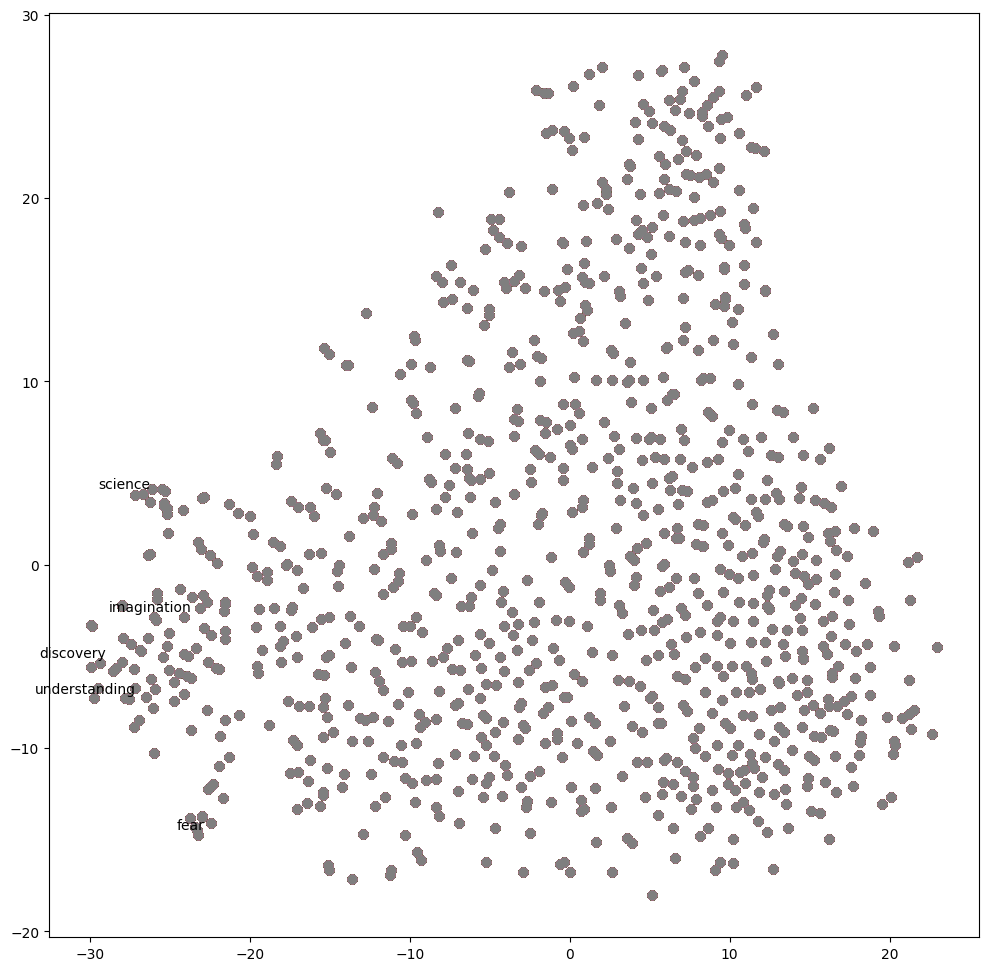

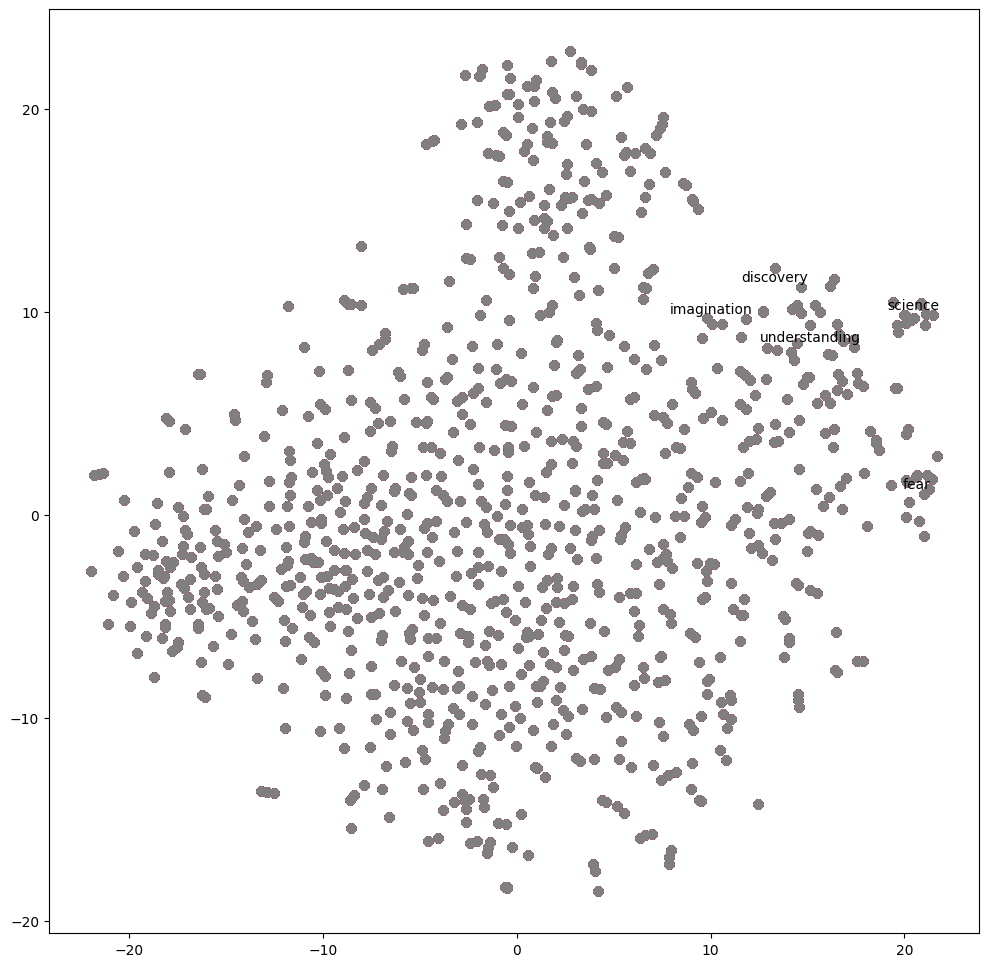

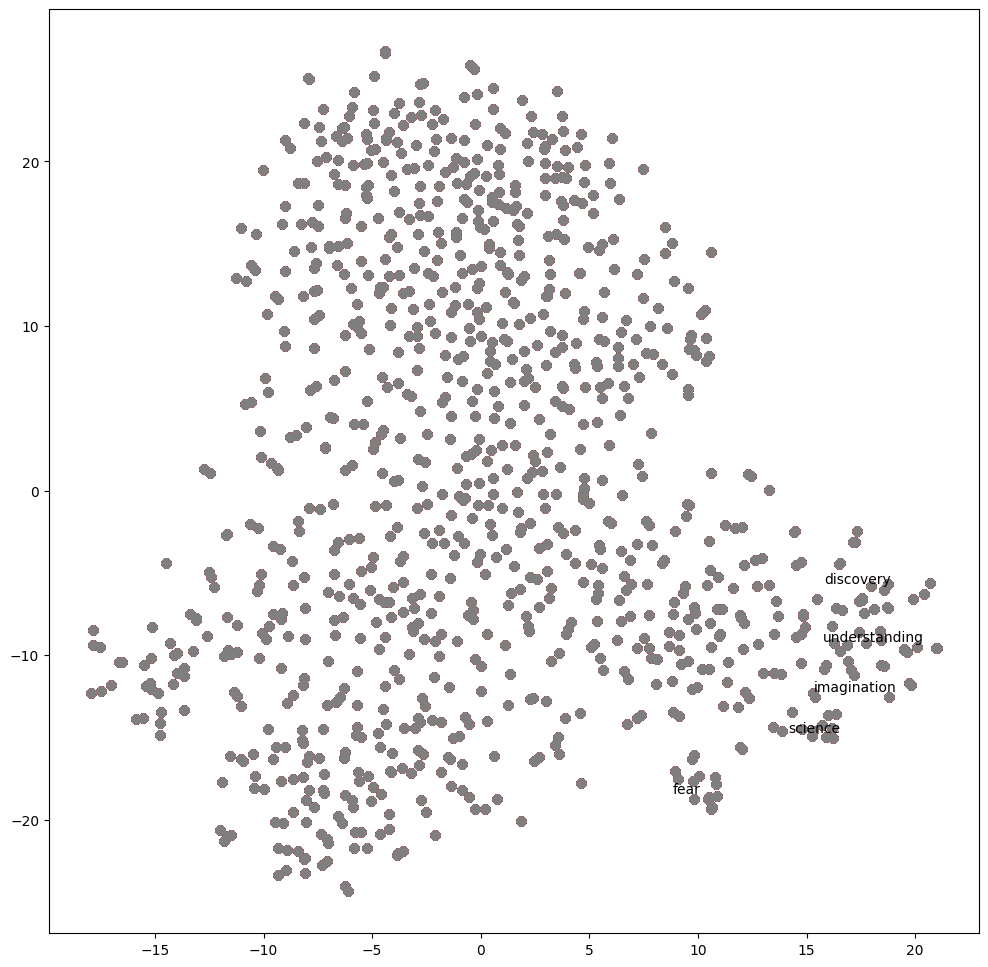

In [59]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt


def reduce_dimensions(model, target_words=None, max_words=1000):
    num_dimensions = 2
    target_words = ['imagination', 'fear', 'understanding', 'discovery', 'science']

    words_to_include = set()
    vectors_list = []
    labels_list = []

    for word in target_words:
        if word in model.wv:
            words_to_include.add(word)

    for word in target_words:
            if word in model.wv:
                try:
                    similar = model.wv.most_similar(word, topn=10)
                    for similar_word, _ in similar:
                        words_to_include.add(similar_word)
                except KeyError:
                    continue

    remaining_slots = max_words - len(words_to_include)
    if remaining_slots > 0:
        all_words = list(model.wv.index_to_key)
        import random
        random.seed(42)
        additional_words = random.sample(all_words, min(remaining_slots, len(all_words)))
        words_to_include.update(additional_words)

    for word in words_to_include:
        if word in model.wv:
            vectors_list.append(model.wv[word])
            labels_list.append(word)

    vectors = np.array(vectors_list)
    labels = np.array(labels_list)

    tsne = TSNE(n_components=num_dimensions, random_state=0, perplexity=min(30, len(vectors)-1))
    vectors = tsne.fit_transform(vectors)

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels

def plot_key_words(x_vals, y_vals, labels):
  """plots the key words using reduced dimensionality"""
  key_words = ['imagination', 'fear', 'understanding', 'discovery', 'science']
  plt.figure(figsize=(12, 12))
  for i in range(len(x_vals)):
    plt.scatter(x_vals, y_vals)

  key_indices =[]
  key_x = []
  key_y = []
  found = []
  for word in key_words:
    word_index = list(labels).index(word)
    key_indices.append(word_index)
    key_x.append(x_vals[word_index])
    key_y.append(y_vals[word_index])
    found.append(word)

  for i, (x, y, word) in enumerate(zip(key_x, key_y, found)):
    plt.annotate(word, xy=(x, y), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
  plt.show()

def tsne(model):
  """calls functions to plot models"""
  x_vals, y_vals, labels = reduce_dimensions(model)
  plot_key_words(x_vals, y_vals, labels)
  return x_vals, y_vals, labels

x_vals, y_vals, labels = tsne(w2vModel1)
x_vals2, y_vals2, labels2 = tsne(w2vModel2)
x_vals3, y_vals3, labels3 = tsne(w2vModel3)

# 1.2.5

In [65]:
df1 = pd.DataFrame({'x': x_vals, 'y': y_vals, 'labels': labels})
df2 = pd.DataFrame({'x': x_vals2, 'y': y_vals2, 'labels': labels2})
df3 = pd.DataFrame({'x': x_vals3, 'y': y_vals3, 'labels': labels3})
key_words = ['imagination', 'fear', 'understanding', 'discovery', 'science']


In [68]:
df1 = df1.loc[df1['labels'].isin(key_words)]
df2 = df2.loc[df2['labels'].isin(key_words)]
df3 = df3.loc[df3['labels'].isin(key_words)]

In [69]:
print(df1)
print(df2)
print(df3)

             x          y         labels
35  -27.570303  -7.305395  understanding
44  -24.105581  -2.871830    imagination
488 -23.257500 -14.762048           fear
641 -29.395739  -5.372087      discovery
906 -26.677425   3.836494        science
             x          y         labels
35   17.419355   8.272826  understanding
44   11.824713   9.652519    imagination
493  21.013615   1.007686           fear
640  14.654854  11.231867      discovery
907  21.474051   9.835392        science
             x          y         labels
35   20.071362  -9.488677  understanding
44   18.800230 -12.535123    imagination
494   9.803572 -18.743650           fear
642  18.548267  -6.012391      discovery
907  16.228329 -15.019828        science


# Part 2
